In [8]:
from cats.cdataframe   import CDataFrame   # tool for extracting data from root files (made by your local developer, Mason Buchanan)
import uproot

In [9]:
import matplotlib.pyplot as plt    # Matplotlib is the most common plotting package for Python

#The next line is a 'magic' command (indicated by the '%'). These tend to do useful meta things.
%matplotlib inline
#This one makes plots show up in your notebooks. (Note that you can't put comments after it on the same line!)

import pandas as pd                # Some additional data-handling tools
import numpy as np                 # "Numerical python". You need this to process data efficiently
import glob                        # Might be useful for getting files
import cdms
from rawio.IO import *             # Useful for reading binary files which contain raw pulses
import ROOT

In [10]:
#DMCfiles = np.sort(glob.glob('/project/6049244/perry/samples/HV100mm_Ge71/DMCOutput_10keV_0V/HV100mm_10keV_0V_51240805_00000?.root')) # Cedar
DMCfiles = np.sort(glob.glob('/project/6049244/perry/samples/HV100mm_Ge71/DMCOutput_1keV_50V/HV100mm_1keV_50V_51240806_00000?.root')) # Cedar

In [11]:
#noisefile = np.sort(glob.glob('/project/6049244/perry/samples/HV100mm_Ge71/processed_10keV_0V/noise/Test_Filter_51240805_000000.root')) # Cedar
noisefile = np.sort(glob.glob('/project/6049244/perry/samples/HV100mm_Ge71/processed_1keV_50V/noise/Test_Filter_51240806_000000.root')) # Cedar

In [19]:
# Open the ROOT file
file = ROOT.TFile.Open(noisefile[0])
hist = file.Get(f'zip14/PTTemplateTime')  # Replace 'histname' with the name of your histogram
# Extract histogram data
n_bins = hist.GetNbinsX()
bin_edges = np.array([hist.GetXaxis().GetBinLowEdge(i) for i in range(1, n_bins + 2)])
bin_contents = np.array([hist.GetBinContent(i) for i in range(1, n_bins + 1)])
# Close the ROOT file
file.Close()

In [20]:
g4dmcTES = CDataFrame('G4SimDir/g4dmcTES', DMCfiles)
Trace_sum = []
for event in range(1000):
    if event % 100 == 0:
        print(event)
    Trace = g4dmcTES.Filter(f'EventNum == {event}').AsNumpy(['Trace'])['Trace']
    Trace = np.array([max(i) - i for i in Trace]) # flip traces right-side up
    Trace_sum.append(np.sum(Trace, axis = 0) / max(np.sum(Trace, axis = 0)))

0
100
200
300
400
500
600
700
800
900


Text(0, 0.5, 'Amplitude [Arb.]')

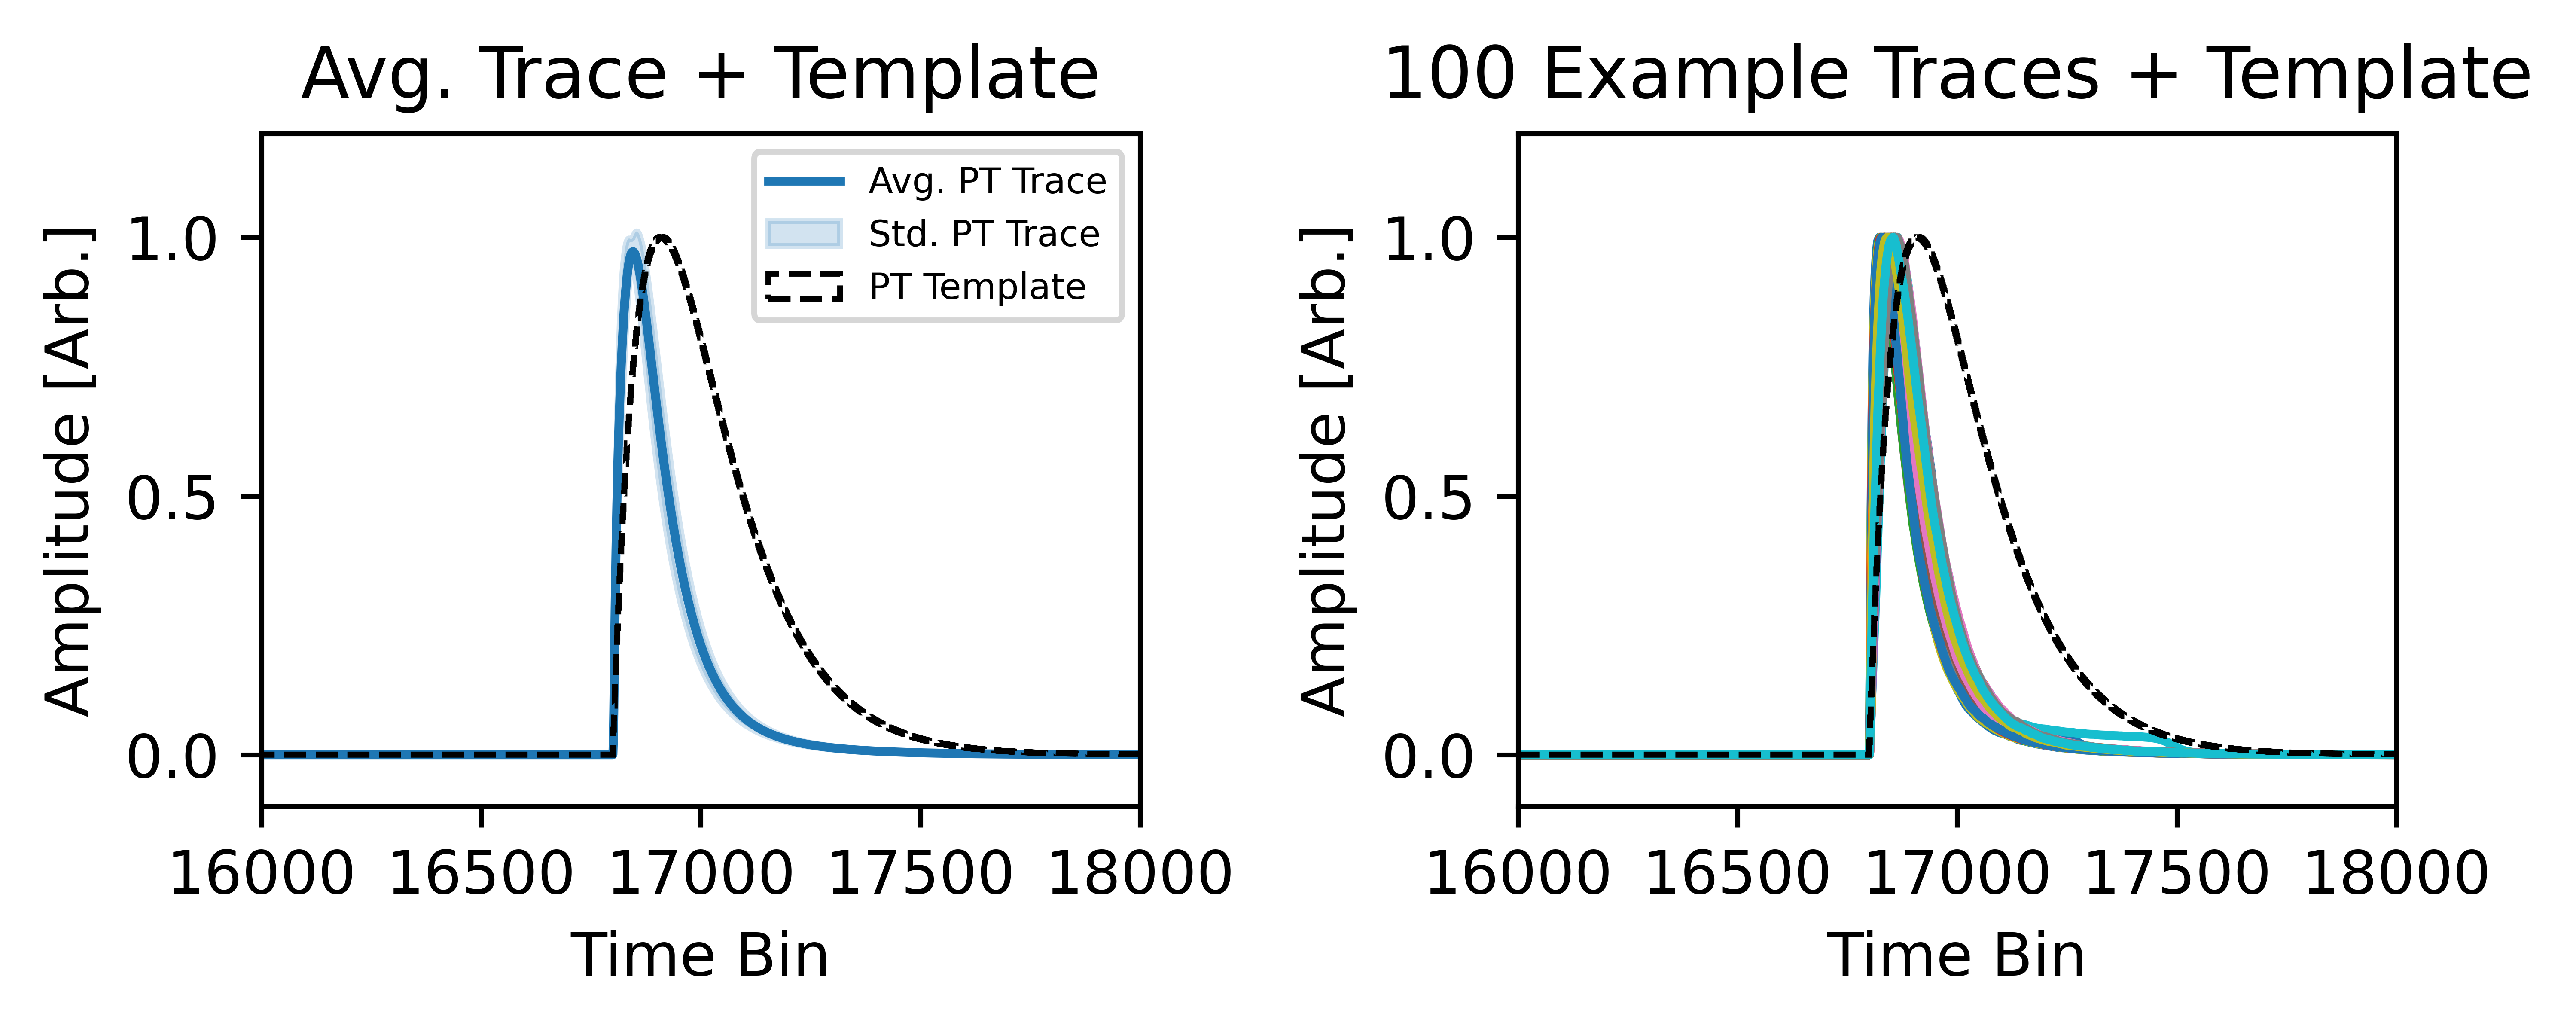

In [21]:
fig1, axes = plt.subplots(1,2,figsize=(6,2.5), dpi = 1000)
fig1.set_tight_layout(True)
    
currentAxis = axes.flatten()[0]
    
currentAxis.plot(np.mean(Trace_sum, axis = 0), color = 'C0', label = 'Avg. PT Trace')

currentAxis.fill_between(np.arange(0, len(Trace_sum[0]), 1), np.mean(Trace_sum, axis = 0), 
                 np.mean(Trace_sum, axis = 0) + np.std(Trace_sum, axis = 0), 
                 color = 'C0', alpha = 0.2, label = "Std. PT Trace")
currentAxis.fill_between(np.arange(0, len(Trace_sum[0]), 1), np.mean(Trace_sum, axis = 0), 
                 np.mean(Trace_sum, axis = 0) - np.std(Trace_sum, axis = 0), 
                 color = 'C0', alpha = 0.2)

currentAxis.hist(bin_edges[:-1], bins=bin_edges, weights=bin_contents, histtype='step', color = 'black', label = f'PT Template', ls='--')
currentAxis.set_xlim(16000, 18000)
currentAxis.set_ylim(-0.1, 1.2)
currentAxis.legend(fontsize = 6)
currentAxis.set_title('Avg. Trace + Template')
currentAxis.set_xlabel('Time Bin')
currentAxis.set_ylabel('Amplitude [Arb.]')
    
currentAxis = axes.flatten()[1]
    
for i in Trace_sum[100:200]:
        
    currentAxis.plot(i)
        
currentAxis.hist(bin_edges[:-1], bins=bin_edges, weights=bin_contents, histtype='step', color = 'black', label = f'Template', ls='--')
currentAxis.set_xlim(16000, 18000)
currentAxis.set_ylim(-0.1, 1.2)
currentAxis.set_title('100 Example Traces + Template')
currentAxis.set_xlabel('Time Bin')
currentAxis.set_ylabel('Amplitude [Arb.]')

Text(0, 0.5, 'Amplitude [$\\mathrm{\\mu A^2 / Hz}$]')

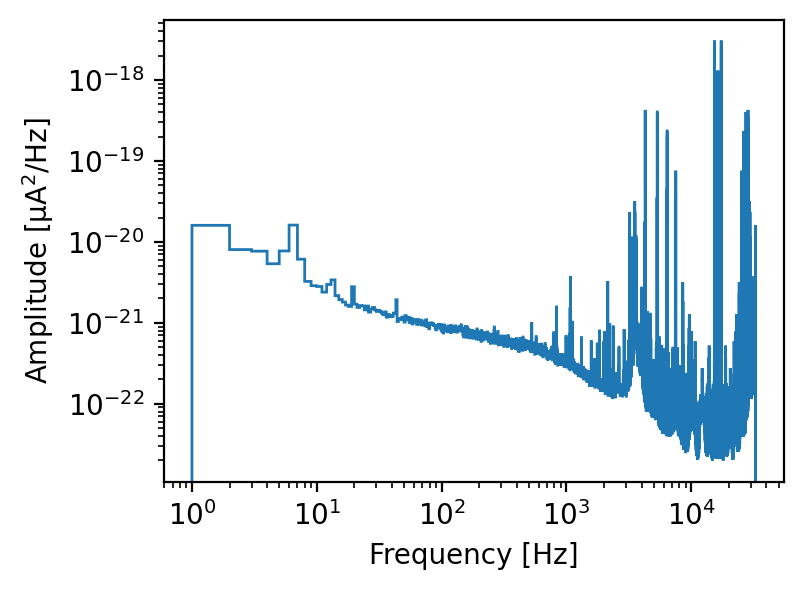

In [5]:
plt.figure(figsize=(4,3), dpi=200)

# Open the ROOT file
file = ROOT.TFile.Open(noisefile[0])
hist = file.Get(f'zip14/PTNoiseFFTsq')  # Replace 'histname' with the name of your histogram
# Extract histogram data
n_bins = hist.GetNbinsX()
bin_edges = np.array([hist.GetXaxis().GetBinLowEdge(i) for i in range(1, n_bins + 2)])
bin_contents = np.array([hist.GetBinContent(i) for i in range(1, n_bins + 1)])
plt.hist(bin_edges[:-1], bins=bin_edges, weights=bin_contents, histtype='step')
# Close the ROOT file
file.Close()

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Frequency [Hz]')
plt.ylabel(r'Amplitude [$\mathrm{\mu A^2 / Hz}$]')

In [12]:
datasets = ['/project/rrg-mdiamond/data/CDMS/CUTE/R37/Processed/Tests/CUTE_T3_GeActivation_v2.1.1_V05-00_P0.2./Noise/CUTE_T3_GeActivation_v2.1.1_V05-00_P0.2._Filter_23231216_100125.root',
            '/project/rrg-mdiamond/data/CDMS/CUTE/R37/Processed/Tests/CUTE_T3_GeActivation_v2.1.1_V05-00_P0.2./Noise/CUTE_T3_GeActivation_v2.1.1_V05-00_P0.2._Filter_23231219_184002.root',
            '/project/rrg-mdiamond/data/CDMS/CUTE/R37/Processed/Tests/CUTE_T3_GeActivation_v2.1.1_V05-00_P0.2./Noise/CUTE_T3_GeActivation_v2.1.1_V05-00_P0.2._Filter_23231220_012745.root',
            '/project/rrg-mdiamond/data/CDMS/CUTE/R37/Processed/Tests/CUTE_T3_GeActivation_v2.1.1_V05-00_P0.2./Noise/CUTE_T3_GeActivation_v2.1.1_V05-00_P0.2._Filter_23231219_110331.root',
            '/project/rrg-mdiamond/data/CDMS/CUTE/R37/Processed/Tests/CUTE_T3_GeActivation_v2.1.1_V05-00_P0.2./Noise/CUTE_T3_GeActivation_v2.1.1_V05-00_P0.2._Filter_23231218_152721.root',
            '/project/rrg-mdiamond/data/CDMS/CUTE/R37/Processed/Tests/CUTE_T3_GeActivation_v2.1.1_V05-00_P0.2./Noise/CUTE_T3_GeActivation_v2.1.1_V05-00_P0.2._Filter_23231218_093255.root',
            '/project/rrg-mdiamond/data/CDMS/CUTE/R37/Processed/Tests/CUTE_T3_GeActivation_v2.1.1_V05-00_P0.2./Noise/CUTE_T3_GeActivation_v2.1.1_V05-00_P0.2._Filter_23231218_223530.root',
            '/project/rrg-mdiamond/data/CDMS/CUTE/R37/Processed/Tests/CUTE_T3_GeActivation_v2.1.1_V05-00_P0.2./Noise/CUTE_T3_GeActivation_v2.1.1_V05-00_P0.2._Filter_23231218_190035.root',
            '/project/rrg-mdiamond/data/CDMS/CUTE/R37/Processed/Tests/CUTE_T3_GeActivation_v2.1.1_V05-00_P0.2./Noise/CUTE_T3_GeActivation_v2.1.1_V05-00_P0.2._Filter_23231219_034952.root',
            '/project/rrg-mdiamond/data/CDMS/CUTE/R37/Processed/Tests/CUTE_T3_GeActivation_v2.1.1_V05-00_P0.2./Noise/CUTE_T3_GeActivation_v2.1.1_V05-00_P0.2._Filter_23231217_171613.root',
            '/project/rrg-mdiamond/data/CDMS/CUTE/R37/Processed/Tests/CUTE_T3_GeActivation_v2.1.1_V05-00_P0.2./Noise/CUTE_T3_GeActivation_v2.1.1_V05-00_P0.2._Filter_23231217_212512.root',
            '/project/rrg-mdiamond/data/CDMS/CUTE/R37/Processed/Tests/CUTE_T3_GeActivation_v2.1.1_V05-00_P0.2./Noise/CUTE_T3_GeActivation_v2.1.1_V05-00_P0.2._Filter_23231216_194929.root',
            '/project/rrg-mdiamond/data/CDMS/CUTE/R37/Processed/Tests/CUTE_T3_GeActivation_v2.1.1_V05-00_P0.2./Noise/CUTE_T3_GeActivation_v2.1.1_V05-00_P0.2._Filter_23231216_115012.root',
            '/project/rrg-mdiamond/data/CDMS/CUTE/R37/Processed/Tests/CUTE_T3_GeActivation_v2.1.1_V05-00_P0.2./Noise/CUTE_T3_GeActivation_v2.1.1_V05-00_P0.2._Filter_23231216_233807.root',
            '/project/rrg-mdiamond/data/CDMS/CUTE/R37/Processed/Tests/CUTE_T3_GeActivation_v2.1.1_V05-00_P0.2./Noise/CUTE_T3_GeActivation_v2.1.1_V05-00_P0.2._Filter_23231216_043946.root',
            '/project/rrg-mdiamond/data/CDMS/CUTE/R37/Processed/Tests/CUTE_T3_GeActivation_v2.1.1_V05-00_P0.2./Noise/CUTE_T3_GeActivation_v2.1.1_V05-00_P0.2._Filter_23231216_182937.root',
            '/project/rrg-mdiamond/data/CDMS/CUTE/R37/Processed/Tests/CUTE_T3_GeActivation_v2.1.1_V05-00_P0.2./Noise/CUTE_T3_GeActivation_v2.1.1_V05-00_P0.2._Filter_23231216_211119.root',
            '/project/rrg-mdiamond/data/CDMS/CUTE/R37/Processed/Tests/CUTE_T3_GeActivation_v2.1.1_V05-00_P0.2./Noise/CUTE_T3_GeActivation_v2.1.1_V05-00_P0.2._Filter_23231217_135018.root',
            '/project/rrg-mdiamond/data/CDMS/CUTE/R37/Processed/Tests/CUTE_T3_GeActivation_v2.1.1_V05-00_P0.2./Noise/CUTE_T3_GeActivation_v2.1.1_V05-00_P0.2._Filter_23231216_013604.root',
            '/project/rrg-mdiamond/data/CDMS/CUTE/R37/Processed/Tests/CUTE_T3_GeActivation_v2.1.1_V05-00_P0.2./Noise/CUTE_T3_GeActivation_v2.1.1_V05-00_P0.2._Filter_23231216_145300.root']

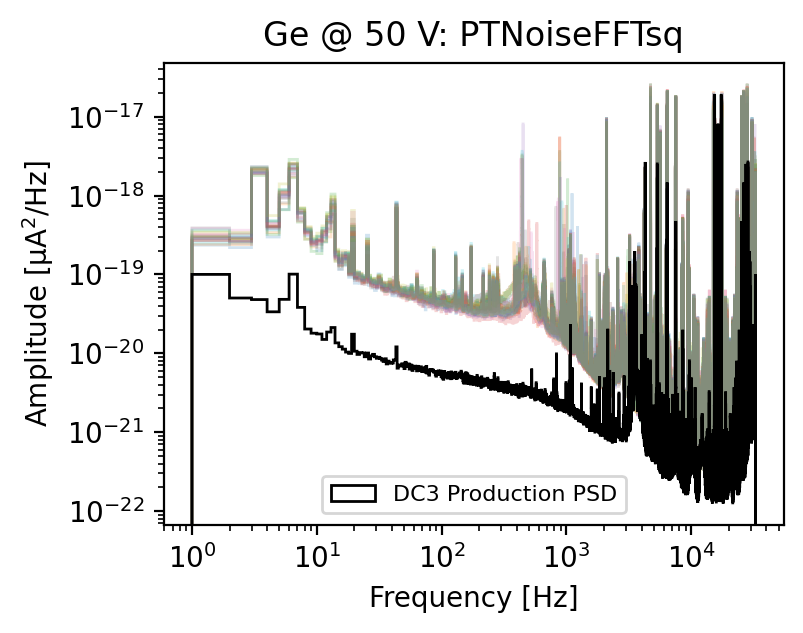

In [13]:
plt.figure(figsize=(4,3), dpi=200)

for data in datasets:

    # Open the ROOT file
    file = ROOT.TFile.Open(data)
    hist = file.Get(f'zip1/PTNoiseFFTsq')  # Replace 'histname' with the name of your histogram
    # Extract histogram data
    n_bins = hist.GetNbinsX()
    bin_edges = np.array([hist.GetXaxis().GetBinLowEdge(i) for i in range(1, n_bins + 2)])
    bin_contents = np.array([hist.GetBinContent(i) for i in range(1, n_bins + 1)])
    plt.hist(bin_edges[:-1], bins=bin_edges, weights=bin_contents, histtype='step', alpha = 0.2)
    # Close the ROOT file
    file.Close()
    
# Open the ROOT file
file = ROOT.TFile.Open(noisefile[0])
hist = file.Get(f'zip14/PTNoiseFFTsq')  # Replace 'histname' with the name of your histogram
# Extract histogram data
n_bins = hist.GetNbinsX()
bin_edges = np.array([hist.GetXaxis().GetBinLowEdge(i) for i in range(1, n_bins + 2)])
bin_contents = np.array([hist.GetBinContent(i) for i in range(1, n_bins + 1)])
plt.hist(bin_edges[:-1], bins=bin_edges, weights=bin_contents*(10/4)**2, histtype='step', color = 'black', label = 'DC3 Production PSD')
# Close the ROOT file
file.Close()
    
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Frequency [Hz]')
plt.ylabel(r'Amplitude [$\mathrm{\mu A^2 / Hz}$]')
plt.title('Ge @ 50 V: PTNoiseFFTsq')
plt.legend(loc = 'lower center', fontsize = 8)

In [29]:
datasets = ['/project/rrg-mdiamond/data/CDMS/CUTE/R37/Processed/Prompt/Prompt_V04-15_P0.2.1/Noise/Prompt_V04-15_P0.2.1_Filter_23231211_215201.root',
 '/project/rrg-mdiamond/data/CDMS/CUTE/R37/Processed/Prompt/Prompt_V04-15_P0.2.1/Noise/Prompt_V04-15_P0.2.1_Filter_23231211_223558.root',
 '/project/rrg-mdiamond/data/CDMS/CUTE/R37/Processed/Prompt/Prompt_V04-15_P0.2.1/Noise/Prompt_V04-15_P0.2.1_Filter_23231213_192731.root',
 '/project/rrg-mdiamond/data/CDMS/CUTE/R37/Processed/Prompt/Prompt_V04-15_P0.2.1/Noise/Prompt_V04-15_P0.2.1_Filter_23231214_100456.root',
 '/project/rrg-mdiamond/data/CDMS/CUTE/R37/Processed/Prompt/Prompt_V04-15_P0.2.1/Noise/Prompt_V04-15_P0.2.1_Filter_23231215_164605.root',
 '/project/rrg-mdiamond/data/CDMS/CUTE/R37/Processed/Prompt/Prompt_V04-15_P0.2.1/Noise/Prompt_V04-15_P0.2.1_Filter_23231215_165936.root',
 '/project/rrg-mdiamond/data/CDMS/CUTE/R37/Processed/Prompt/Prompt_V04-15_P0.2.1/Noise/Prompt_V04-15_P0.2.1_Filter_23231221_223301.root',
 '/project/rrg-mdiamond/data/CDMS/CUTE/R37/Processed/Prompt/Prompt_V04-15_P0.2.1/Noise/Prompt_V04-15_P0.2.1_Filter_23231221_235414.root',
 '/project/rrg-mdiamond/data/CDMS/CUTE/R37/Processed/Prompt/Prompt_V04-15_P0.2.1/Noise/Prompt_V04-15_P0.2.1_Filter_23231222_074513.root',
 '/project/rrg-mdiamond/data/CDMS/CUTE/R37/Processed/Prompt/Prompt_V04-15_P0.2.1/Noise/Prompt_V04-15_P0.2.1_Filter_23231227_154945.root',
 #'/project/rrg-mdiamond/data/CDMS/CUTE/R37/Processed/Prompt/Prompt_V04-15_P0.2.1/Noise/Prompt_V04-15_P0.2.1_Filter_23240102_153258.root',
 #'/project/rrg-mdiamond/data/CDMS/CUTE/R37/Processed/Prompt/Prompt_V04-15_P0.2.1/Noise/Prompt_V04-15_P0.2.1_Filter_23240102_175328.root',
 #'/project/rrg-mdiamond/data/CDMS/CUTE/R37/Processed/Prompt/Prompt_V04-15_P0.2.1/Noise/Prompt_V04-15_P0.2.1_Filter_23240102_191543.root',
 #'/project/rrg-mdiamond/data/CDMS/CUTE/R37/Processed/Prompt/Prompt_V04-15_P0.2.1/Noise/Prompt_V04-15_P0.2.1_Filter_23240102_205017.root',
 #'/project/rrg-mdiamond/data/CDMS/CUTE/R37/Processed/Prompt/Prompt_V04-15_P0.2.1/Noise/Prompt_V04-15_P0.2.1_Filter_23240102_225220.root',
 #'/project/rrg-mdiamond/data/CDMS/CUTE/R37/Processed/Prompt/Prompt_V04-15_P0.2.1/Noise/Prompt_V04-15_P0.2.1_Filter_23240103_072548.root',
 #'/project/rrg-mdiamond/data/CDMS/CUTE/R37/Processed/Prompt/Prompt_V04-15_P0.2.1/Noise/Prompt_V04-15_P0.2.1_Filter_23240103_151214.root',
 #'/project/rrg-mdiamond/data/CDMS/CUTE/R37/Processed/Prompt/Prompt_V04-15_P0.2.1/Noise/Prompt_V04-15_P0.2.1_Filter_23240103_163330.root',
 #'/project/rrg-mdiamond/data/CDMS/CUTE/R37/Processed/Prompt/Prompt_V04-15_P0.2.1/Noise/Prompt_V04-15_P0.2.1_Filter_23240103_171125.root',
 '/project/rrg-mdiamond/data/CDMS/CUTE/R37/Processed/Prompt/Prompt_V04-15_P0.2.1/Noise/Prompt_V04-15_P0.2.1_Filter_23240103_172239.root',
 '/project/rrg-mdiamond/data/CDMS/CUTE/R37/Processed/Prompt/Prompt_V04-15_P0.2.1/Noise/Prompt_V04-15_P0.2.1_Filter_23240103_192502.root',
 '/project/rrg-mdiamond/data/CDMS/CUTE/R37/Processed/Prompt/Prompt_V04-15_P0.2.1/Noise/Prompt_V04-15_P0.2.1_Filter_23240103_200057.root',
 '/project/rrg-mdiamond/data/CDMS/CUTE/R37/Processed/Prompt/Prompt_V04-15_P0.2.1/Noise/Prompt_V04-15_P0.2.1_Filter_23240103_222641.root']

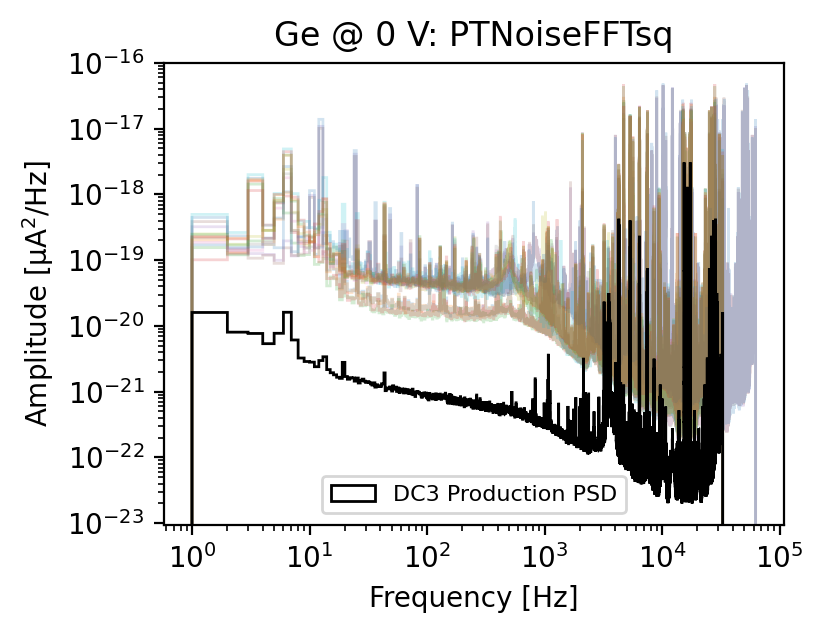

In [30]:
plt.figure(figsize=(4,3), dpi=200)

for data in datasets:

    # Open the ROOT file
    file = ROOT.TFile.Open(data)
    hist = file.Get(f'zip1/PTNoiseFFTsq')  # Replace 'histname' with the name of your histogram
    # Extract histogram data
    n_bins = hist.GetNbinsX()
    bin_edges = np.array([hist.GetXaxis().GetBinLowEdge(i) for i in range(1, n_bins + 2)])
    bin_contents = np.array([hist.GetBinContent(i) for i in range(1, n_bins + 1)])
    plt.hist(bin_edges[:-1], bins=bin_edges, weights=bin_contents, histtype='step', alpha = 0.2)
    # Close the ROOT file
    file.Close()
    
# Open the ROOT file
file = ROOT.TFile.Open(noisefile[0])
hist = file.Get(f'zip14/PTNoiseFFTsq')  # Replace 'histname' with the name of your histogram
# Extract histogram data
n_bins = hist.GetNbinsX()
bin_edges = np.array([hist.GetXaxis().GetBinLowEdge(i) for i in range(1, n_bins + 2)])
bin_contents = np.array([hist.GetBinContent(i) for i in range(1, n_bins + 1)])
plt.hist(bin_edges[:-1], bins=bin_edges, weights=bin_contents, histtype='step', color = 'black', label = 'DC3 Production PSD')
# Close the ROOT file
file.Close()
    
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Frequency [Hz]')
plt.ylabel(r'Amplitude [$\mathrm{\mu A^2 / Hz}$]')
plt.title('Ge @ 0 V: PTNoiseFFTsq')
plt.legend(loc = 'lower center', fontsize = 8)